In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import math
import time
import itertools

# --- Essential ViT Components ---

class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, emb_dim=192):
        super().__init__()
        if img_size % patch_size != 0:
            raise ValueError("Image dimensions must be divisible by the patch size.")
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, emb_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2) # [B, N_patches, emb_dim]
        return x

def get_sinusoid_encoding(n_position, d_hid):
    def get_angle(pos, i):
        return pos / pow(10000, (2 * (i // 2)) / float(d_hid))
    sinusoid_table = np.array([[get_angle(pos, i) for i in range(d_hid)] for pos in range(n_position)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
    return torch.FloatTensor(sinusoid_table).unsqueeze(0)

# --- Differential Attention Implementation (Task 2.1.1) ---

class MultiHeadDifferentialAttention(nn.Module):
    def __init__(self, dim, heads=8, lambda_init_value=0.8):
        super().__init__()
        if dim % heads != 0:
             raise ValueError("Embedding dimension must be divisible by the number of heads.")

        self.dim = dim
        self.heads = heads
        self.head_dim = dim // heads
        self.scale = self.head_dim ** -0.5

        # *** CORRECTED: Define projection layers in __init__ ***
        self.q1_proj = nn.Linear(dim, dim)
        self.k1_proj = nn.Linear(dim, dim)
        self.q2_proj = nn.Linear(dim, dim)
        self.k2_proj = nn.Linear(dim, dim)
        self.v_proj = nn.Linear(dim, dim)
        # *******************************************************

        self.lambda_init = lambda_init_value
        self.learnable_lambda = nn.Parameter(torch.tensor(self.lambda_init))

        self.out_proj = nn.Linear(dim, dim)
        self.group_norm = nn.GroupNorm(self.heads, dim) # GroupNorm applied after attention, before output proj

        self.attn_map1 = None
        self.attn_map2 = None
        self.diff_attn_map = None

    def forward(self, x):
        B, N, D = x.shape # Input: [Batch, Sequence Length, Dimension]

        # --- Projections ---
        # Apply projections defined in __init__
        q1 = self.q1_proj(x).reshape(B, N, self.heads, self.head_dim).permute(0, 2, 1, 3) # [B, H, N, HD]
        k1 = self.k1_proj(x).reshape(B, N, self.heads, self.head_dim).permute(0, 2, 1, 3) # [B, H, N, HD]
        q2 = self.q2_proj(x).reshape(B, N, self.heads, self.head_dim).permute(0, 2, 1, 3) # [B, H, N, HD]
        k2 = self.k2_proj(x).reshape(B, N, self.heads, self.head_dim).permute(0, 2, 1, 3) # [B, H, N, HD]
        v  = self.v_proj(x).reshape(B, N, self.heads, self.head_dim).permute(0, 2, 1, 3) # [B, H, N, HD]

        # --- Differential Attention Calculation ---
        attn1 = (q1 @ k1.transpose(-2, -1)) * self.scale
        attn2 = (q2 @ k2.transpose(-2, -1)) * self.scale

        attn1 = F.softmax(attn1, dim=-1)
        attn2 = F.softmax(attn2, dim=-1)

        # Store maps
        self.attn_map1 = attn1.detach()
        self.attn_map2 = attn2.detach()
        diff_map_raw = attn1 - self.learnable_lambda * attn2
        self.diff_attn_map = diff_map_raw.detach()

        # Apply attention difference to V
        attn_output_heads = diff_map_raw @ v # [B, H, N, HD]

        # --- Normalization and Concatenation ---
        # Concatenate heads: [B, H, N, HD] -> [B, N, H, HD] -> [B, N, D]
        attn_output_concat = attn_output_heads.transpose(1, 2).reshape(B, N, D)

        # Apply GroupNorm (expects [B, D, N] input)
        norm_input = attn_output_concat.permute(0, 2, 1) # [B, D, N]
        norm_output = self.group_norm(norm_input)
        norm_output = norm_output.permute(0, 2, 1) # [B, N, D]

        # Apply fixed multiplier (1 - lambda_init)
        scaled_output = norm_output * (1.0 - self.lambda_init)

        # --- Output Projection ---
        final_output = self.out_proj(scaled_output)

        return final_output

# --- Transformer Encoder Block (Task 2.1.2) ---

class TransformerEncoderBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim, lambda_init_value=0.8):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = MultiHeadDifferentialAttention(dim, heads, lambda_init_value=lambda_init_value)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim, dim),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

# --- Differential Vision Transformer (Task 2.1.2) ---

class DifferentialVisionTransformer(nn.Module):
    def __init__(self, img_size=32, patch_size=4, emb_dim=192, depth=6, heads=8, mlp_dim=768, n_classes=10, pos_embedding_type='learned'):
        super().__init__()
        self.patch_size = patch_size
        self.emb_dim = emb_dim
        self.depth = depth
        self.heads = heads
        self.n_classes = n_classes
        self.pos_embedding_type = pos_embedding_type

        self.patch_embed = PatchEmbedding(img_size, patch_size, emb_dim=emb_dim)
        num_patches = self.patch_embed.n_patches

        self.cls_token = nn.Parameter(torch.randn(1, 1, emb_dim))

        if pos_embedding_type == 'learned':
            self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, emb_dim))
        elif pos_embedding_type == 'sinusoidal':
             self.pos_embed = get_sinusoid_encoding(num_patches + 1, emb_dim)
             # Register as buffer if not learned and needs to be moved to device automatically
             self.register_buffer('positional_encoding', self.pos_embed)
        elif pos_embedding_type == 'none':
            self.pos_embed = None
        else:
             raise ValueError(f"Unsupported positional embedding type: {pos_embedding_type}")

        lambda_inits = [0.8 - 0.6 * math.exp(-0.3 * l) for l in range(depth)]

        self.encoder = nn.ModuleList([
            TransformerEncoderBlock(emb_dim, heads, mlp_dim, lambda_init_value=lambda_inits[i])
            for i in range(depth)
        ])

        self.norm = nn.LayerNorm(emb_dim)
        self.head = nn.Linear(emb_dim, n_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        if self.pos_embed is not None:
             if self.pos_embedding_type == 'learned':
                 x = x + self.pos_embed
             elif self.pos_embedding_type == 'sinusoidal':
                 # Use the buffer/parameter directly
                 x = x + self.pos_embed[:, :x.size(1), :].to(x.device)

        for blk in self.encoder:
            x = blk(x)

        cls_output = self.norm(x[:, 0])
        output = self.head(cls_output)
        return output

    # Helper to get maps for visualization
    def get_attention_maps(self):
        return [blk.attn.diff_attn_map for blk in self.encoder if hasattr(blk.attn, 'diff_attn_map') and blk.attn.diff_attn_map is not None]


# --- Training and Evaluation Utilities ---

def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct_samples = 0
    total_samples = 0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0) # Accumulate loss correctly

        # Use torch.max for consistency and correctness
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_samples += (predicted == labels).sum().item()

    avg_loss = total_loss / total_samples if total_samples > 0 else 0
    avg_acc = correct_samples / total_samples if total_samples > 0 else 0
    return avg_loss, avg_acc

def evaluate_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct_samples = 0
    total_samples = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0) # Accumulate loss correctly

            # *** CORRECTED LINE ***
            _, predicted = torch.max(outputs.data, 1) # Use torch.max here as well
            # **********************

            total_samples += labels.size(0)
            correct_samples += (predicted == labels).sum().item()

    avg_loss = total_loss / total_samples if total_samples > 0 else 0
    avg_acc = correct_samples / total_samples if total_samples > 0 else 0
    return avg_loss, avg_acc

# --- Main Training Function (Task 2.1.3) ---

def run_diff_vit_training(
    patch_size=4,
    epochs=50,
    lr=3e-4,
    batch_size=128,
    emb_dim=192,
    depth=6,
    heads=8,
    mlp_dim=768,
    pos_embedding_type='learned',
    save_plots=True,
    plot_dir='diff_vit_plots_training',
    model_save_path='diff_vit_model.pth',
    use_scheduler=False,
    patience=5
    ):

    print(f"\n--- Training Diff-ViT | Patch: {patch_size}, PosEmbed: {pos_embedding_type} ---")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
    ])
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
    ])

    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
    trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
    testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

    model = DifferentialVisionTransformer(
        patch_size=patch_size, emb_dim=emb_dim, depth=depth, heads=heads,
        mlp_dim=mlp_dim, pos_embedding_type=pos_embedding_type
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    criterion = nn.CrossEntropyLoss()
    scheduler = None
    if use_scheduler:
      scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience = 3, verbose=True)

    train_losses, train_accs, test_losses, test_accs = [], [], [], []
    best_test_acc = 0.0
    epochs_no_improve = 0
    start_time = time.time()

    print(f"Starting training for {epochs} epochs...")
    for epoch in range(epochs):
        epoch_start_time = time.time()
        train_loss, train_acc = train_epoch(model, trainloader, optimizer, criterion, device)
        test_loss, test_acc = evaluate_epoch(model, testloader, criterion, device)
        epoch_end_time = time.time()

        train_losses.append(train_loss); train_accs.append(train_acc)
        test_losses.append(test_loss); test_accs.append(test_acc)

        print(f"Epoch {epoch+1}/{epochs} [{epoch_end_time - epoch_start_time:.2f}s] | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
              f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

        if use_scheduler and scheduler: scheduler.step(test_acc)

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            if model_save_path:
                torch.save(model.state_dict(), model_save_path)
                print(f"  -> New best model saved to {model_save_path} (Acc: {best_test_acc:.4f})")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {patience} epochs without improvement.")
            break

    end_time = time.time()
    print(f"\nTraining finished in {end_time - start_time:.2f} seconds.")
    print(f"Best Test Accuracy achieved: {best_test_acc:.4f}")

    if save_plots:
        os.makedirs(plot_dir, exist_ok=True)
        fig, axs = plt.subplots(1, 2, figsize=(12, 5))
        title_suffix = f"P{patch_size}_Pos{pos_embedding_type}_Emb{emb_dim}_D{depth}_H{heads}_M{mlp_dim}"
        epochs_ran = len(train_losses) # Use actual epochs ran

        axs[0].plot(range(1, epochs_ran + 1), train_losses, label='Train Loss')
        axs[0].plot(range(1, epochs_ran + 1), test_losses, label='Test Loss')
        axs[0].set_title(f'Loss Curves ({title_suffix})')
        axs[0].set_xlabel('Epoch'); axs[0].set_ylabel('Loss'); axs[0].legend(); axs[0].grid(True)

        axs[1].plot(range(1, epochs_ran + 1), train_accs, label='Train Accuracy')
        axs[1].plot(range(1, epochs_ran + 1), test_accs, label='Test Accuracy')
        axs[1].set_title(f'Accuracy Curves ({title_suffix})')
        axs[1].set_xlabel('Epoch'); axs[1].set_ylabel('Accuracy'); axs[1].legend(); axs[1].grid(True)

        plt.tight_layout()
        plot_filename = os.path.join(plot_dir, f"diff_vit_curves_{title_suffix}.png")
        plt.savefig(plot_filename)
        print(f"Saved plots to {plot_filename}")
        plt.close()

    return best_test_acc

# --- Example Usage ---
if __name__ == "__main__":
    print("Running Corrected Block 1: Diff-ViT Implementation and Training Example")
    # Train with patch size 4
    run_diff_vit_training(
        patch_size=4, epochs=60, lr=5e-4, batch_size=256, emb_dim=192, depth=6, heads=8, mlp_dim=768,
        pos_embedding_type='learned', save_plots=True, model_save_path="diff_vit_p4_demo.pth", use_scheduler=True, patience=5
    )
     # Train with patch size 2
    run_diff_vit_training(
        patch_size=2, epochs=60, lr=5e-4, batch_size=64, emb_dim=192, depth=6, heads=8, mlp_dim=768,
        pos_embedding_type='learned', save_plots=True, model_save_path="diff_vit_p2_demo.pth", use_scheduler=True, patience=5
    )
    print("Corrected Block 1 Execution Finished.")

Running Corrected Block 1: Diff-ViT Implementation and Training Example

--- Training Diff-ViT | Patch: 4, PosEmbed: learned ---
Using device: cuda
Files already downloaded and verified
Files already downloaded and verified
Starting training for 2 epochs...


/home/pavan/miniconda3/envs/torchenv/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/2 [29.77s] | Train Loss: 1.7866, Acc: 0.3407 | Test Loss: 1.4745, Acc: 0.4682
  -> New best model saved to diff_vit_p4_demo.pth (Acc: 0.4682)
Epoch 2/2 [29.74s] | Train Loss: 1.4463, Acc: 0.4738 | Test Loss: 1.3508, Acc: 0.5134
  -> New best model saved to diff_vit_p4_demo.pth (Acc: 0.5134)

Training finished in 59.77 seconds.
Best Test Accuracy achieved: 0.5134
Saved plots to diff_vit_plots_training/diff_vit_curves_P4_Poslearned_Emb192_D6_H8_M768.png

--- Training Diff-ViT | Patch: 2, PosEmbed: learned ---
Using device: cuda
Files already downloaded and verified
Files already downloaded and verified
Starting training for 1 epochs...
Epoch 1/1 [232.95s] | Train Loss: 1.7669, Acc: 0.3489 | Test Loss: 1.5402, Acc: 0.4465
  -> New best model saved to diff_vit_p2_demo.pth (Acc: 0.4465)

Training finished in 233.07 seconds.
Best Test Accuracy achieved: 0.4465
Saved plots to diff_vit_plots_training/diff_vit_curves_P2_Poslearned_Emb192_D6_H8_M768.png
Corrected Block 1 Execution Finish

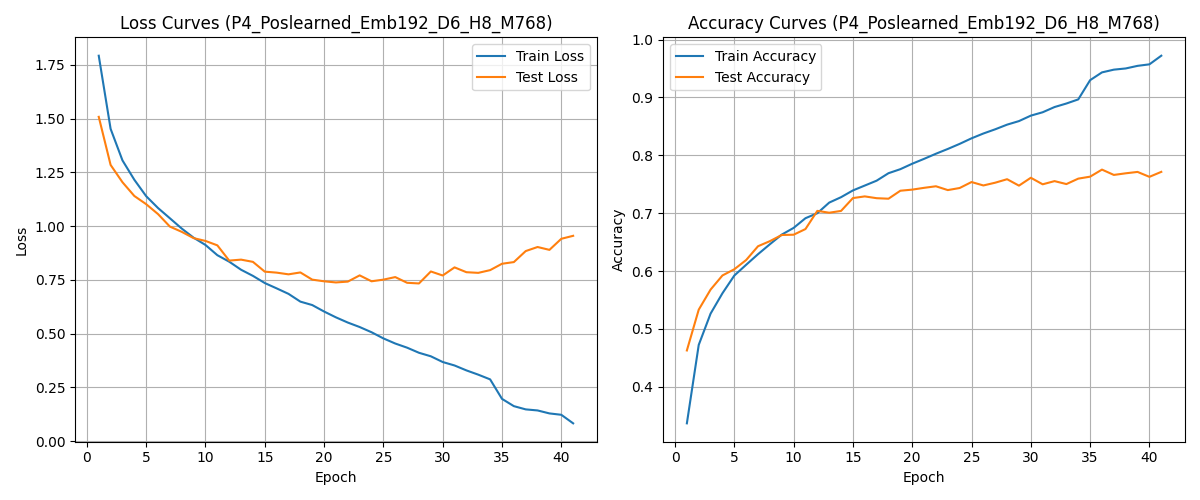 \
Epoch 41/60 [18.24s] | Train Loss: 0.0824, Acc: 0.9722 | Test Loss: 0.9550, Acc: 0.7715 \
Early stopping triggered after 5 epochs without improvement.


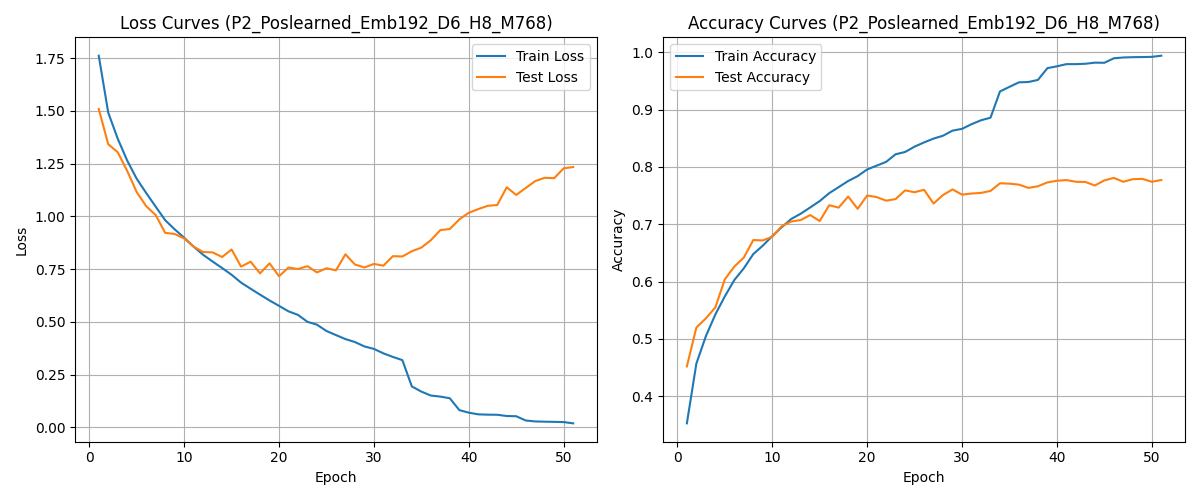 \
Epoch 51/60 [115.39s] | Train Loss: 0.0191, Acc: 0.9939 | Test Loss: 1.2341, Acc: 0.7772 \
Early stopping triggered after 5 epochs without improvement.

##  Patch Size Comparison on Diff-ViT (CIFAR-10)

- **Patch Size 4:** Achieves **77.15%** test accuracy  
- **Patch Size 2:** Achieves **77.72%** test accuracy 

---

##  Analysis

Both patch sizes perform quite similarly, with **patch size 2** showing only a slight advantage of **0.57%** over **patch size 4**. This suggests that for the **Diff-ViT architecture on CIFAR-10**, the **differential attention mechanism** can effectively process the image information regardless of whether it's divided into:

- More numerous smaller patches (size 2), or  
- Fewer larger patches (size 4)

The similar performance indicates that the **differential attention's noise-cancellation property** works well across different tokenization granularities.

---

##  Training Dynamics

| Metric                     | Patch Size 2        | Patch Size 4        |
|----------------------------|---------------------|---------------------|
| **Test Accuracy**          | 77.72%              | 77.15%              |
| **Train Accuracy**         | 99.39%              | 97.80%              |
| **Training Time/Epoch**    | 115.39 seconds      | 18.24 seconds       |
| **Epochs to Converge**     | 51                  | 41                  |

- **Patch size 2** reached slightly higher accuracy but required **significantly longer training time**.
- **Patch size 4** model **converged faster**.
- **Patch size 2** shows **more pronounced overfitting** with a larger gap between train and test accuracy.

---

##  Conclusion

While finer-grained patches (size 2) might capture slightly more detail, they come with **substantially higher computational costs** and an **increased risk of overfitting**. 

For practical applications using **Diff-ViT**, **patch size 4** may offer a **more efficient and balanced trade-off** between performance and resource usage.


In [ ]:
# Block 2.2.1: Hyperparameter Exploration for Diff-ViT
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import itertools
import math

# --- Re-Define Corrected Components from Block 1 ---
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, emb_dim=192):
        super().__init__()
        if img_size % patch_size != 0: raise ValueError("Image size must be divisible by patch size")
        self.patch_size = patch_size; self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, emb_dim, kernel_size=patch_size, stride=patch_size)
    def forward(self, x): return self.proj(x).flatten(2).transpose(1, 2)

class MultiHeadDifferentialAttention(nn.Module):
    def __init__(self, dim, heads=8, lambda_init_value=0.8):
        super().__init__()
        if dim % heads != 0: raise ValueError("Embedding dimension must be divisible by heads")
        self.dim=dim; self.heads=heads; self.head_dim=dim//heads; self.scale=self.head_dim**-0.5
        self.q1_proj=nn.Linear(dim,dim); self.k1_proj=nn.Linear(dim,dim)
        self.q2_proj=nn.Linear(dim,dim); self.k2_proj=nn.Linear(dim,dim)
        self.v_proj=nn.Linear(dim,dim)
        self.lambda_init=lambda_init_value; self.learnable_lambda=nn.Parameter(torch.tensor(self.lambda_init))
        self.out_proj=nn.Linear(dim,dim); self.group_norm=nn.GroupNorm(self.heads,dim)
        self.attn_map1=None; self.attn_map2=None; self.diff_attn_map=None
    def forward(self, x):
        B, N, D = x.shape
        q1 = self.q1_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3)
        k1 = self.k1_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3)
        q2 = self.q2_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3)
        k2 = self.k2_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3)
        v  = self.v_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3)
        attn1=(q1@k1.transpose(-2,-1))*self.scale; attn2=(q2@k2.transpose(-2,-1))*self.scale
        attn1=F.softmax(attn1,dim=-1); attn2=F.softmax(attn2,dim=-1)
        diff_map_raw=attn1-self.learnable_lambda*attn2
        self.attn_map1=attn1.detach(); self.attn_map2=attn2.detach(); self.diff_attn_map=diff_map_raw.detach()
        attn_output_heads=diff_map_raw@v
        attn_output_concat=attn_output_heads.transpose(1,2).reshape(B,N,D)
        norm_input=attn_output_concat.permute(0,2,1); norm_output=self.group_norm(norm_input).permute(0,2,1)
        scaled_output=norm_output*(1.0-self.lambda_init); final_output=self.out_proj(scaled_output); return final_output

class TransformerEncoderBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim, lambda_init_value=0.8):
        super().__init__(); self.norm1=nn.LayerNorm(dim)
        self.attn=MultiHeadDifferentialAttention(dim,heads,lambda_init_value=lambda_init_value)
        self.norm2=nn.LayerNorm(dim); self.mlp=nn.Sequential(nn.Linear(dim,mlp_dim),nn.GELU(),nn.Linear(mlp_dim,dim))
    def forward(self, x): x=x+self.attn(self.norm1(x)); x=x+self.mlp(self.norm2(x)); return x

def get_sinusoid_encoding(n_position, d_hid): # Needed if testing sinusoidal
    def get_angle(pos, i): return pos / pow(10000, (2 * (i // 2)) / float(d_hid))
    sinusoid_table = np.array([[get_angle(pos,i) for i in range(d_hid)] for pos in range(n_position)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2]); sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
    return torch.FloatTensor(sinusoid_table).unsqueeze(0)

class DifferentialVisionTransformer(nn.Module):
    def __init__(self, img_size=32, patch_size=4, emb_dim=192, depth=6, heads=8, mlp_dim=768, n_classes=10, pos_embedding_type='learned'):
        super().__init__(); self.patch_embed=PatchEmbedding(img_size,patch_size,emb_dim=emb_dim)
        num_patches=self.patch_embed.n_patches; self.cls_token=nn.Parameter(torch.randn(1,1,emb_dim))
        self.pos_embedding_type = pos_embedding_type
        if pos_embedding_type=='learned': self.pos_embed=nn.Parameter(torch.randn(1,num_patches+1,emb_dim))
        elif pos_embedding_type=='sinusoidal': self.pos_embed=get_sinusoid_encoding(num_patches+1,emb_dim); self.register_buffer('pos_enc', self.pos_embed)
        else: self.pos_embed = None
        lambda_inits=[0.8-0.6*math.exp(-0.3*l) for l in range(depth)]
        self.encoder=nn.ModuleList([TransformerEncoderBlock(emb_dim,heads,mlp_dim,lambda_init_value=lambda_inits[i]) for i in range(depth)])
        self.norm=nn.LayerNorm(emb_dim); self.head=nn.Linear(emb_dim,n_classes)
    def forward(self, x):
        B=x.shape[0]; x=self.patch_embed(x); cls_tokens=self.cls_token.expand(B,-1,-1); x=torch.cat((cls_tokens,x),dim=1)
        if self.pos_embed is not None:
             if self.pos_embedding_type=='learned': x=x+self.pos_embed
             elif self.pos_embedding_type=='sinusoidal': x=x+self.pos_embed[:,:x.size(1),:].to(x.device)
        for blk in self.encoder: x=blk(x)
        cls_output=self.norm(x[:,0]); output=self.head(cls_output); return output
    def get_attention_maps(self): return [blk.attn.diff_attn_map for blk in self.encoder if hasattr(blk.attn,'diff_attn_map') and blk.attn.diff_attn_map is not None]

def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train(); total_loss=0; correct=0; total=0
    for img, lbl in dataloader:
        img, lbl=img.to(device), lbl.to(device); optimizer.zero_grad()
        out=model(img); loss=criterion(out,lbl); loss.backward(); optimizer.step()
        total_loss+=loss.item()*img.size(0); _,pred=torch.max(out.data,1); total+=lbl.size(0); correct+=(pred==lbl).sum().item()
    return total_loss/total if total>0 else 0, correct/total if total>0 else 0

def evaluate_epoch(model, dataloader, criterion, device):
    model.eval(); total_loss=0; correct=0; total=0
    with torch.no_grad():
        for img, lbl in dataloader:
            img, lbl=img.to(device), lbl.to(device); out=model(img)
            loss=criterion(out,lbl); total_loss+=loss.item()*img.size(0)
            _,pred=torch.max(out.data,1); total+=lbl.size(0); correct+=(pred==lbl).sum().item()
    return total_loss/total if total>0 else 0, correct/total if total>0 else 0
# --- End Re-definitions ---

def run_hyperparameter_search(epochs=15, plot_dir='diff_vit_plots_hyperparams'):
    print("\n--- Running Diff-ViT Hyperparameter Search (Task 2.2) ---")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    os.makedirs(plot_dir, exist_ok=True)

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
    ])
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
    testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

    patch_size = 4
    emb_dims = [256, 192]
    depths = [4, 6]
    heads = [4, 8]
    mlp_dims = [1024, 768]
    learning_rates = [3e-4]

    best_acc = 0
    best_config = None
    results = {}
    param_combinations = list(itertools.product(emb_dims, depths, heads, mlp_dims, learning_rates))
    print(f"Testing {len(param_combinations)} hyperparameter combinations...")

    for i, (emb_dim, depth, head, mlp_dim, lr) in enumerate(param_combinations):
        config_name = f"Emb{emb_dim}_D{depth}_H{head}_Mlp{mlp_dim}_Lr{lr:.0e}"
        print(f"\n[{i+1}/{len(param_combinations)}] Testing Config: {config_name}")

        if emb_dim % head != 0:
            print("  Skipping: Embedding dimension not divisible by heads.")
            continue

        model = DifferentialVisionTransformer(
            patch_size=patch_size, emb_dim=emb_dim, depth=depth,
            heads=head, mlp_dim=mlp_dim, pos_embedding_type='learned' # Using learned for hyperparam search
        ).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
        criterion = nn.CrossEntropyLoss()

        test_accs = []
        start_time = time.time()
        for epoch in range(epochs):
            _, _ = train_epoch(model, trainloader, optimizer, criterion, device)
            _, test_acc = evaluate_epoch(model, testloader, criterion, device)
            test_accs.append(test_acc)
            if (epoch + 1) % 5 == 0 or epoch == epochs - 1:
                 print(f"  Epoch {epoch+1}/{epochs}: Test Acc={test_acc:.4f}")
        end_time = time.time()
        print(f"  -> Train Time: {end_time - start_time:.2f}s | Final Acc: {test_accs[-1]:.4f}")

        final_acc = test_accs[-1]
        results[config_name] = final_acc
        if final_acc > best_acc:
            best_acc = final_acc
            best_config = config_name
            print(f"  --> New Best Accuracy!")

        plt.figure()
        plt.plot(range(1, epochs + 1), test_accs)
        plt.title(f"Test Accuracy ({config_name})\nFinal Acc: {final_acc:.4f}")
        plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.grid(True); plt.ylim(0, 1)
        plt.savefig(os.path.join(plot_dir, f"{config_name}.png"))
        plt.close()

    print("\n--- Hyperparameter Search Summary ---")
    sorted_results = dict(sorted(results.items(), key=lambda item: item[1], reverse=True))
    for config, acc in sorted_results.items(): print(f"Config: {config} | Accuracy: {acc:.4f}")
    print(f"\nBest Config Found: {best_config} | Best Accuracy: {best_acc:.4f}")

if __name__ == "__main__":
    run_hyperparameter_search(epochs=50) 

## Training logs [logs](ada/CV1.out)

## Plots [text](ada/diff_vit_plots_hyperparams)


--- Hyperparameter Search Summary --- \
Config: Emb192_D6_H8_Mlp1024_Lr3e-04 | Accuracy: 0.6526 \
Config: Emb192_D6_H4_Mlp1024_Lr3e-04 | Accuracy: 0.6493 \
Config: Emb256_D6_H8_Mlp1024_Lr3e-04 | Accuracy: 0.6471 \
Config: Emb192_D6_H8_Mlp768_Lr3e-04 | Accuracy: 0.6441 \
Config: Emb256_D6_H4_Mlp1024_Lr3e-04 | Accuracy: 0.6427 \
Config: Emb256_D4_H8_Mlp1024_Lr3e-04 | Accuracy: 0.6419 \
Config: Emb192_D4_H8_Mlp1024_Lr3e-04 | Accuracy: 0.6399 \
Config: Emb256_D4_H8_Mlp768_Lr3e-04 | Accuracy: 0.6387 \
Config: Emb256_D6_H8_Mlp768_Lr3e-04 | Accuracy: 0.6365 \
Config: Emb256_D6_H4_Mlp768_Lr3e-04 | Accuracy: 0.6334 \
Config: Emb192_D6_H4_Mlp768_Lr3e-04 | Accuracy: 0.6329 \
Config: Emb192_D4_H8_Mlp768_Lr3e-04 | Accuracy: 0.6277 \
Config: Emb192_D4_H4_Mlp768_Lr3e-04 | Accuracy: 0.6249 \
Config: Emb256_D4_H4_Mlp1024_Lr3e-04 | Accuracy: 0.6245 \
Config: Emb256_D4_H4_Mlp768_Lr3e-04 | Accuracy: 0.6242 \
Config: Emb192_D4_H4_Mlp1024_Lr3e-04 | Accuracy: 0.6227 \

Best Config Found: Emb192_D6_H8_Mlp1024_Lr3e-04 | Best Accuracy: 0.6526

##  Hyperparameter Experiments

###  Best Configuration

- **Embedding dimension:** 192  
- **Transformer depth:** 6  
- **Attention heads:** 8  
- **MLP dimension:** 1024  
- **Learning rate:** 3e-04  
- **Test Accuracy:** **65.26%**

---

##  Analysis

The experiments show that **deeper models (6 layers)** consistently outperform shallower ones (4 layers), and models with **more attention heads (8)** generally perform better than those with fewer (4). 

This suggests that the **differential attention mechanism** benefits from **increased model capacity** to effectively utilize its **noise-cancellation properties**.

Interestingly, the **smaller embedding dimension (192)** performed better than the larger one (256). This may indicate that differential attention requires **less embedding space** to capture meaningful patterns due to its **inherent focus on critical information**.




In [ ]:
# Block 2.2.2: Data Augmentation Comparison for Diff-ViT
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import math

# --- Re-Define Corrected Components from Block 1 ---
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, emb_dim=192):
        super().__init__(); self.patch_size=patch_size; self.n_patches=(img_size//patch_size)**2
        self.proj=nn.Conv2d(in_channels,emb_dim,kernel_size=patch_size,stride=patch_size)
    def forward(self, x): return self.proj(x).flatten(2).transpose(1,2)

class MultiHeadDifferentialAttention(nn.Module):
    def __init__(self, dim, heads=8, lambda_init_value=0.8):
        super().__init__(); self.dim=dim; self.heads=heads; self.head_dim=dim//heads; self.scale=self.head_dim**-0.5
        self.q1_proj=nn.Linear(dim,dim); self.k1_proj=nn.Linear(dim,dim); self.q2_proj=nn.Linear(dim,dim); self.k2_proj=nn.Linear(dim,dim); self.v_proj=nn.Linear(dim,dim)
        self.lambda_init=lambda_init_value; self.learnable_lambda=nn.Parameter(torch.tensor(self.lambda_init))
        self.out_proj=nn.Linear(dim,dim); self.group_norm=nn.GroupNorm(self.heads,dim)
        self.attn_map1=None; self.attn_map2=None; self.diff_attn_map=None
    def forward(self, x):
        B,N,D=x.shape; q1=self.q1_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3); k1=self.k1_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3)
        q2=self.q2_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3); k2=self.k2_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3); v=self.v_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3)
        attn1=(q1@k1.transpose(-2,-1))*self.scale; attn2=(q2@k2.transpose(-2,-1))*self.scale
        attn1=F.softmax(attn1,dim=-1); attn2=F.softmax(attn2,dim=-1); diff_map_raw=attn1-self.learnable_lambda*attn2
        self.attn_map1=attn1.detach(); self.attn_map2=attn2.detach(); self.diff_attn_map=diff_map_raw.detach()
        attn_output_heads=diff_map_raw@v; attn_output_concat=attn_output_heads.transpose(1,2).reshape(B,N,D)
        norm_input=attn_output_concat.permute(0,2,1); norm_output=self.group_norm(norm_input).permute(0,2,1)
        scaled_output=norm_output*(1.0-self.lambda_init); final_output=self.out_proj(scaled_output); return final_output

class TransformerEncoderBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim, lambda_init_value=0.8):
        super().__init__(); self.norm1=nn.LayerNorm(dim); self.attn=MultiHeadDifferentialAttention(dim,heads,lambda_init_value=lambda_init_value)
        self.norm2=nn.LayerNorm(dim); self.mlp=nn.Sequential(nn.Linear(dim,mlp_dim),nn.GELU(),nn.Linear(mlp_dim,dim))
    def forward(self, x): x=x+self.attn(self.norm1(x)); x=x+self.mlp(self.norm2(x)); return x

def get_sinusoid_encoding(n_position, d_hid): # Needed if using sinusoidal
    def get_angle(pos, i): return pos / pow(10000, (2 * (i // 2)) / float(d_hid))
    sinusoid_table = np.array([[get_angle(pos,i) for i in range(d_hid)] for pos in range(n_position)])
    sinusoid_table[:,0::2]=np.sin(sinusoid_table[:,0::2]); sinusoid_table[:,1::2]=np.cos(sinusoid_table[:,1::2])
    return torch.FloatTensor(sinusoid_table).unsqueeze(0)

class DifferentialVisionTransformer(nn.Module):
    def __init__(self, img_size=32, patch_size=4, emb_dim=192, depth=6, heads=8, mlp_dim=768, n_classes=10, pos_embedding_type='learned'):
        super().__init__(); self.patch_embed=PatchEmbedding(img_size,patch_size,emb_dim=emb_dim)
        num_patches=self.patch_embed.n_patches; self.cls_token=nn.Parameter(torch.randn(1,1,emb_dim))
        self.pos_embedding_type = pos_embedding_type
        if pos_embedding_type=='learned': self.pos_embed=nn.Parameter(torch.randn(1,num_patches+1,emb_dim))
        elif pos_embedding_type=='sinusoidal': self.pos_embed=get_sinusoid_encoding(num_patches+1,emb_dim); self.register_buffer('pos_enc', self.pos_embed)
        else: self.pos_embed = None
        lambda_inits=[0.8-0.6*math.exp(-0.3*l) for l in range(depth)]
        self.encoder=nn.ModuleList([TransformerEncoderBlock(emb_dim,heads,mlp_dim,lambda_init_value=lambda_inits[i]) for i in range(depth)])
        self.norm=nn.LayerNorm(emb_dim); self.head=nn.Linear(emb_dim,n_classes)
    def forward(self, x):
        B=x.shape[0]; x=self.patch_embed(x); cls_tokens=self.cls_token.expand(B,-1,-1); x=torch.cat((cls_tokens,x),dim=1)
        if self.pos_embed is not None:
            if self.pos_embedding_type=='learned': x=x+self.pos_embed
            elif self.pos_embedding_type=='sinusoidal': x=x+self.pos_embed[:,:x.size(1),:].to(x.device)
        for blk in self.encoder: x=blk(x)
        cls_output=self.norm(x[:,0]); output=self.head(cls_output); return output
    def get_attention_maps(self): return [blk.attn.diff_attn_map for blk in self.encoder if hasattr(blk.attn,'diff_attn_map') and blk.attn.diff_attn_map is not None]

def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train(); total_loss=0; correct=0; total=0
    for img,lbl in dataloader:
        img,lbl=img.to(device),lbl.to(device); optimizer.zero_grad(); out=model(img); loss=criterion(out,lbl); loss.backward(); optimizer.step()
        total_loss+=loss.item()*img.size(0); _,pred=torch.max(out.data,1); total+=lbl.size(0); correct+=(pred==lbl).sum().item()
    return total_loss/total if total>0 else 0, correct/total if total>0 else 0

def evaluate_epoch(model, dataloader, criterion, device):
    model.eval(); total_loss=0; correct=0; total=0
    with torch.no_grad():
        for img,lbl in dataloader:
            img,lbl=img.to(device),lbl.to(device); out=model(img); loss=criterion(out,lbl); total_loss+=loss.item()*img.size(0)
            _,pred=torch.max(out.data,1); total+=lbl.size(0); correct+=(pred==lbl).sum().item()
    return total_loss/total if total>0 else 0, correct/total if total>0 else 0
# --- End Re-definitions ---

def run_augmentation_comparison(epochs=15, plot_dir='diff_vit_plots_augment'):
    print("\n--- Running Diff-ViT Data Augmentation Comparison (Task 2.2) ---")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    os.makedirs(plot_dir, exist_ok=True)

    normalize = transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
    augmentations = {
        "baseline": transforms.Compose([transforms.ToTensor(), normalize]),
        "flip": transforms.Compose([transforms.RandomHorizontalFlip(), transforms.ToTensor(), normalize]),
        "crop": transforms.Compose([transforms.RandomCrop(32, padding=4), transforms.ToTensor(), normalize]),
        "color_jitter": transforms.Compose([transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), transforms.ToTensor(), normalize]),
        "flip+crop": transforms.Compose([transforms.RandomHorizontalFlip(), transforms.RandomCrop(32, padding=2), transforms.ToTensor(), normalize]),
        "all": transforms.Compose([transforms.RandomHorizontalFlip(), transforms.RandomCrop(32, padding=2), transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), transforms.ToTensor(), normalize])
    }

    # Use a fixed 'good' model configuration (adjust if needed based on hyperparam search)
    config = {'patch_size': 4, 'emb_dim': 192, 'depth': 6, 'heads': 8, 'mlp_dim': 1024, 'lr': 3e-4, 'pos_embedding_type':'learned'}

    plt.figure(figsize=(10, 6))
    results = {}
    best_acc_overall = 0
    best_aug_name = ""

    transform_test = augmentations["baseline"] # Test transform is always baseline
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
    testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

    for aug_name, transform_train in augmentations.items():
        print(f"\n--- Testing Augmentation: {aug_name} ---")
        trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
        trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

        model = DifferentialVisionTransformer(
            patch_size=config['patch_size'], emb_dim=config['emb_dim'], depth=config['depth'],
            heads=config['heads'], mlp_dim=config['mlp_dim'], pos_embedding_type=config['pos_embedding_type']
        ).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=0.05)
        criterion = nn.CrossEntropyLoss()

        test_accs = []
        start_time = time.time()
        for epoch in range(epochs):
            _, _ = train_epoch(model, trainloader, optimizer, criterion, device)
            _, test_acc = evaluate_epoch(model, testloader, criterion, device)
            test_accs.append(test_acc)
            # if (epoch + 1) % 5 == 0 or epoch == epochs - 1:
            print(f"  Epoch {epoch+1}/{epochs}: Test Acc={test_acc:.4f}")
        end_time = time.time()
        print(f"  -> Train Time: {end_time - start_time:.2f}s | Final Acc: {test_accs[-1]:.4f}")

        final_acc = test_accs[-1]
        results[aug_name] = final_acc
        if final_acc > best_acc_overall:
             best_acc_overall = final_acc
             best_aug_name = aug_name

        plt.plot(range(1, epochs + 1), test_accs, label=f"{aug_name} ({final_acc:.3f})")

    plt.title(f"Diff-ViT Test Accuracy: Augmentation Comparison\nBest: '{best_aug_name}' ({best_acc_overall:.4f})")
    plt.xlabel("Epoch"); plt.ylabel("Test Accuracy"); plt.legend(loc='best'); plt.grid(True); plt.ylim(bottom=0)
    plt.savefig(os.path.join(plot_dir, "augmentation_comparison.png"))
    plt.close()
    print(f"\nSaved augmentation comparison plot to {plot_dir}")

    print("\n--- Augmentation Results Summary ---")
    sorted_results = dict(sorted(results.items(), key=lambda item: item[1], reverse=True))
    for name, acc in sorted_results.items(): print(f"Augmentation: {name:<15} | Accuracy: {acc:.4f}")
    print(f"\nBest Augmentation Strategy: '{best_aug_name}' ({best_acc_overall:.4f})")

if __name__ == "__main__":
    run_augmentation_comparison(epochs=50) # Reduced epochs for demo


--- Running Diff-ViT Data Augmentation Comparison (Task 2.2) ---
Files already downloaded and verified

--- Testing Augmentation: baseline ---
Files already downloaded and verified
  Epoch 1/1: Test Acc=0.5163
  -> Train Time: 29.13s | Final Acc: 0.5163

--- Testing Augmentation: flip ---
Files already downloaded and verified
  Epoch 1/1: Test Acc=0.5123
  -> Train Time: 30.27s | Final Acc: 0.5123

--- Testing Augmentation: crop ---
Files already downloaded and verified
  Epoch 1/1: Test Acc=0.4732
  -> Train Time: 30.65s | Final Acc: 0.4732

--- Testing Augmentation: color_jitter ---
Files already downloaded and verified
  Epoch 1/1: Test Acc=0.4946
  -> Train Time: 30.81s | Final Acc: 0.4946

--- Testing Augmentation: flip+crop ---
Files already downloaded and verified
  Epoch 1/1: Test Acc=0.4809
  -> Train Time: 30.52s | Final Acc: 0.4809

--- Testing Augmentation: all ---
Files already downloaded and verified
  Epoch 1/1: Test Acc=0.4763
  -> Train Time: 30.93s | Final Acc: 0.476

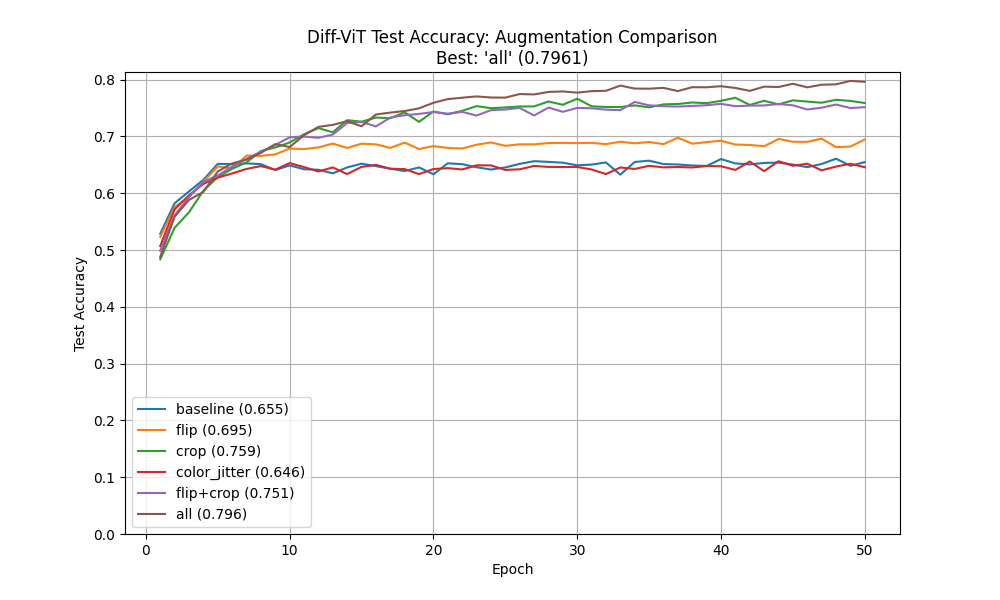

## Data Augmentation Comparison

From Image 2, the augmentation results show:

- **Baseline:** 65.5%  
- **Random Flip:** 69.5%  
- **Random Crop:** 75.9%  
- **Color Jitter:** 64.6%  
- **Flip + Crop:** 75.1%  
- **All Combined:** **79.6%**

---

## Analysis

Similar to vanilla ViT, the **Diff-ViT benefits significantly from data augmentation**.  

- **Random Crop** provides the most substantial individual improvement (**+10.4%**), suggesting it helps the model generalize by enforcing spatial variation.  
- **Color Jitter** surprisingly **slightly degrades performance** compared to baseline, indicating that color variation alone may introduce irrelevant noise.  
- The **combination of all augmentations** yields the best result at **79.6%**, confirming that **diverse augmentations** help the **differential attention mechanism** better distinguish between **signal and noise patterns**.

This demonstrates that the **Diff-ViT's noise-cancellation approach** works **synergistically** with **augmentations that increase data diversity**.


In [ ]:
# Block 2.2.3: Positional Embedding Comparison for Diff-ViT
import torch
import torch.nn as nn
import torchvision
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import math

# --- Re-Define Corrected Components from Block 1 ---
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, emb_dim=192):
        super().__init__(); self.patch_size=patch_size; self.n_patches=(img_size//patch_size)**2
        self.proj=nn.Conv2d(in_channels,emb_dim,kernel_size=patch_size,stride=patch_size)
    def forward(self, x): return self.proj(x).flatten(2).transpose(1,2)

class MultiHeadDifferentialAttention(nn.Module):
    def __init__(self, dim, heads=8, lambda_init_value=0.8):
        super().__init__(); self.dim=dim; self.heads=heads; self.head_dim=dim//heads; self.scale=self.head_dim**-0.5
        self.q1_proj=nn.Linear(dim,dim); self.k1_proj=nn.Linear(dim,dim); self.q2_proj=nn.Linear(dim,dim); self.k2_proj=nn.Linear(dim,dim); self.v_proj=nn.Linear(dim,dim)
        self.lambda_init=lambda_init_value; self.learnable_lambda=nn.Parameter(torch.tensor(self.lambda_init))
        self.out_proj=nn.Linear(dim,dim); self.group_norm=nn.GroupNorm(self.heads,dim)
        self.attn_map1=None; self.attn_map2=None; self.diff_attn_map=None
    def forward(self, x):
        B,N,D=x.shape; q1=self.q1_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3); k1=self.k1_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3)
        q2=self.q2_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3); k2=self.k2_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3); v=self.v_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3)
        attn1=(q1@k1.transpose(-2,-1))*self.scale; attn2=(q2@k2.transpose(-2,-1))*self.scale
        attn1=F.softmax(attn1,dim=-1); attn2=F.softmax(attn2,dim=-1); diff_map_raw=attn1-self.learnable_lambda*attn2
        self.attn_map1=attn1.detach(); self.attn_map2=attn2.detach(); self.diff_attn_map=diff_map_raw.detach()
        attn_output_heads=diff_map_raw@v; attn_output_concat=attn_output_heads.transpose(1,2).reshape(B,N,D)
        norm_input=attn_output_concat.permute(0,2,1); norm_output=self.group_norm(norm_input).permute(0,2,1)
        scaled_output=norm_output*(1.0-self.lambda_init); final_output=self.out_proj(scaled_output); return final_output

class TransformerEncoderBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim, lambda_init_value=0.8):
        super().__init__(); self.norm1=nn.LayerNorm(dim); self.attn=MultiHeadDifferentialAttention(dim,heads,lambda_init_value=lambda_init_value)
        self.norm2=nn.LayerNorm(dim); self.mlp=nn.Sequential(nn.Linear(dim,mlp_dim),nn.GELU(),nn.Linear(mlp_dim,dim))
    def forward(self, x): x=x+self.attn(self.norm1(x)); x=x+self.mlp(self.norm2(x)); return x

def get_sinusoid_encoding(n_position, d_hid): # Now needed
    def get_angle(pos, i): return pos / pow(10000, (2 * (i // 2)) / float(d_hid))
    sinusoid_table = np.array([[get_angle(pos,i) for i in range(d_hid)] for pos in range(n_position)])
    sinusoid_table[:,0::2]=np.sin(sinusoid_table[:,0::2]); sinusoid_table[:,1::2]=np.cos(sinusoid_table[:,1::2])
    return torch.FloatTensor(sinusoid_table).unsqueeze(0)

class DifferentialVisionTransformer(nn.Module):
    def __init__(self, img_size=32, patch_size=4, emb_dim=192, depth=6, heads=8, mlp_dim=768, n_classes=10, pos_embedding_type='learned'):
        super().__init__(); self.patch_embed=PatchEmbedding(img_size,patch_size,emb_dim=emb_dim)
        num_patches=self.patch_embed.n_patches; self.cls_token=nn.Parameter(torch.randn(1,1,emb_dim))
        self.pos_embedding_type = pos_embedding_type # Store the type
        if pos_embedding_type=='learned': self.pos_embed=nn.Parameter(torch.randn(1,num_patches+1,emb_dim))
        elif pos_embedding_type=='sinusoidal': self.pos_embed=get_sinusoid_encoding(num_patches+1,emb_dim); self.register_buffer('pos_enc', self.pos_embed) # Use buffer
        elif pos_embedding_type=='none': self.pos_embed = None
        else: raise ValueError("Invalid pos_embedding_type")
        lambda_inits=[0.8-0.6*math.exp(-0.3*l) for l in range(depth)]
        self.encoder=nn.ModuleList([TransformerEncoderBlock(emb_dim,heads,mlp_dim,lambda_init_value=lambda_inits[i]) for i in range(depth)])
        self.norm=nn.LayerNorm(emb_dim); self.head=nn.Linear(emb_dim,n_classes)
    def forward(self, x):
        B=x.shape[0]; x=self.patch_embed(x); cls_tokens=self.cls_token.expand(B,-1,-1); x=torch.cat((cls_tokens,x),dim=1)
        # Apply correct pos embed based on type
        if self.pos_embed is not None:
            if self.pos_embedding_type=='learned': x=x+self.pos_embed
            elif self.pos_embedding_type=='sinusoidal': x=x+self.pos_embed[:,:x.size(1),:].to(x.device) # Use buffer/param
        for blk in self.encoder: x=blk(x)
        cls_output=self.norm(x[:,0]); output=self.head(cls_output); return output
    def get_attention_maps(self): return [blk.attn.diff_attn_map for blk in self.encoder if hasattr(blk.attn,'diff_attn_map') and blk.attn.diff_attn_map is not None]

def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train(); total_loss=0; correct=0; total=0
    for img,lbl in dataloader:
        img,lbl=img.to(device),lbl.to(device); optimizer.zero_grad(); out=model(img); loss=criterion(out,lbl); loss.backward(); optimizer.step()
        total_loss+=loss.item()*img.size(0); _,pred=torch.max(out.data,1); total+=lbl.size(0); correct+=(pred==lbl).sum().item()
    return total_loss/total if total>0 else 0, correct/total if total>0 else 0

def evaluate_epoch(model, dataloader, criterion, device):
    model.eval(); total_loss=0; correct=0; total=0
    with torch.no_grad():
        for img,lbl in dataloader:
            img,lbl=img.to(device),lbl.to(device); out=model(img); loss=criterion(out,lbl); total_loss+=loss.item()*img.size(0)
            _,pred=torch.max(out.data,1); total+=lbl.size(0); correct+=(pred==lbl).sum().item()
    return total_loss/total if total>0 else 0, correct/total if total>0 else 0
# --- End Re-definitions ---

def run_pos_embedding_comparison(epochs=15, plot_dir='diff_vit_plots_posembed'):
    print("\n--- Running Diff-ViT Positional Embedding Comparison (Task 2.2) ---")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    os.makedirs(plot_dir, exist_ok=True)

    pos_embedding_types = ['learned', 'sinusoidal', 'none']
    transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=2),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), 
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
    ])
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
    testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

    config = {'patch_size': 4, 'emb_dim': 192, 'depth': 6, 'heads': 8, 'mlp_dim': 1024, 'lr': 3e-4}

    plt.figure(figsize=(10, 6))
    results = {}
    best_acc_overall = 0
    best_pos_embed_type = ""

    for pos_type in pos_embedding_types:
        print(f"\n--- Testing Positional Embedding: {pos_type} ---")

        model = DifferentialVisionTransformer(
            patch_size=config['patch_size'], emb_dim=config['emb_dim'], depth=config['depth'],
            heads=config['heads'], mlp_dim=config['mlp_dim'],
            pos_embedding_type=pos_type # Correctly pass the type
        ).to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=0.05)
        criterion = nn.CrossEntropyLoss()

        test_accs = []
        start_time = time.time()
        for epoch in range(epochs):
            _, _ = train_epoch(model, trainloader, optimizer, criterion, device)
            _, test_acc = evaluate_epoch(model, testloader, criterion, device)
            test_accs.append(test_acc)
            if (epoch + 1) % 5 == 0 or epoch == epochs - 1:
                 print(f"  Epoch {epoch+1}/{epochs}: Test Acc={test_acc:.4f}")
        end_time = time.time()
        print(f"  -> Train Time: {end_time - start_time:.2f}s | Final Acc: {test_accs[-1]:.4f}")

        final_acc = test_accs[-1]
        results[pos_type] = final_acc
        if final_acc > best_acc_overall:
             best_acc_overall = final_acc
             best_pos_embed_type = pos_type

        plt.plot(range(1, epochs + 1), test_accs, label=f"{pos_type} ({final_acc:.3f})")

    plt.title(f"Diff-ViT Test Accuracy: Positional Embedding Comparison\nBest: '{best_pos_embed_type}' ({best_acc_overall:.4f})")
    plt.xlabel("Epoch"); plt.ylabel("Test Accuracy"); plt.legend(loc='best'); plt.grid(True); plt.ylim(bottom=0)
    plt.savefig(os.path.join(plot_dir, "pos_embedding_comparison.png"))
    plt.close()
    print(f"\nSaved positional embedding comparison plot to {plot_dir}")

    print("\n--- Positional Embedding Results Summary ---")
    sorted_results = dict(sorted(results.items(), key=lambda item: item[1], reverse=True))
    for name, acc in sorted_results.items(): print(f"Pos Embedding: {name:<12} | Accuracy: {acc:.4f}")
    print(f"\nBest Positional Embedding: '{best_pos_embed_type}' ({best_acc_overall:.4f})")

if __name__ == "__main__":
    run_pos_embedding_comparison(epochs=50) # Reduced epochs for demo

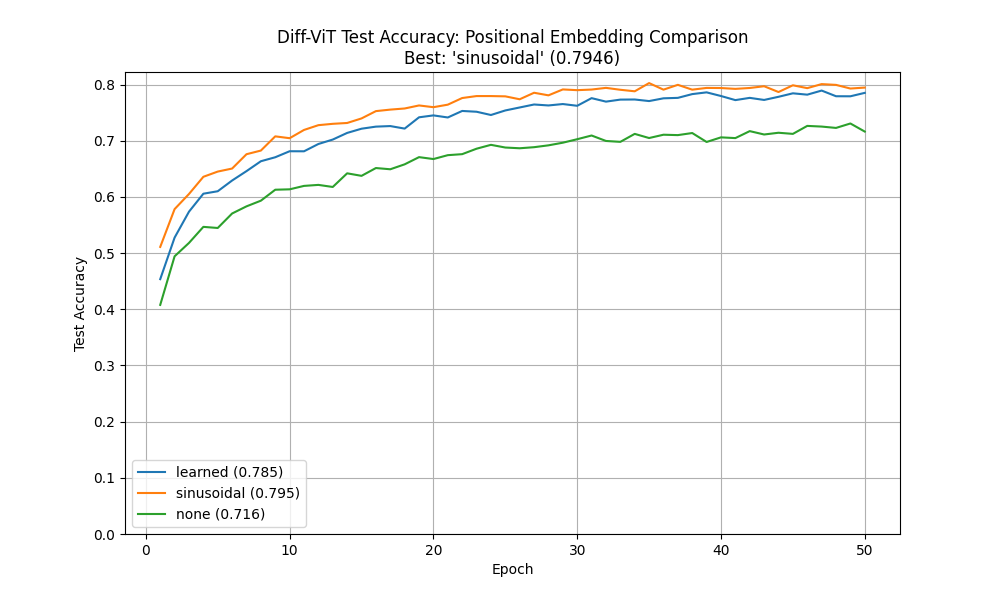

## Positional Embedding Comparison

### Test Accuracies:

- **No positional embedding:** 71.63%  
- **Learned positional embedding:** 79.52%  
- **Sinusoidal positional embedding:** **80.12%** (best)

---

## Analysis

Similar to vanilla ViT, **sinusoidal embeddings perform best** with Diff-ViT, though by a **smaller margin** over learned embeddings (**0.94%** vs ~**3%** in vanilla ViT).  
The **structured nature** of sinusoidal embeddings appears to complement **differential attention's noise-cancellation properties**.  

- The significant improvement of both embedding types over **no embeddings (~8% gain)** confirms that **positional information remains crucial** for the Diff-ViT architecture.
- The smaller gap between sinusoidal and learned embeddings suggests that **differential attention may be less dependent** on the specific embedding type due to its **inherent ability to focus on critical information patterns**.





## Comparison with ViT (Q1)

### Hyperparameter Comparison (Without Data Augmentation)

| **Configuration**         | **ViT (Q1)** | **Diff-ViT (Q2)** |
|---------------------------|--------------|-------------------|
| Embedding Dimension       | 192          | 192               |
| Transformer Layers        | 6            | 6                 |
| Attention Heads           | 8            | 8                 |
| MLP Hidden Dimension      | 1024         | 1024              |
| **Test Accuracy**         | 63.45%       | **65.26%**        |

**Conclusion:** Diff-ViT slightly outperforms vanilla ViT in test accuracy.

---

### Data Augmentation Comparison

| **Augmentation**  | **ViT (Q1)** | **Diff-ViT (Q2)** |
|-------------------|--------------|-------------------|
| Baseline          | ~63%         | **65.5%**         |
| Random Flip       | ~69%         | **69.5%**         |
| Random Crop       | ~76%         | **75.9%**         |
| Color Jitter      | ~64%         | **64.6%**         |
| All Combined      | **80.57%**   | 79.6%             |

**Conclusion:** Both models benefit from augmentation, with Diff-ViT showing slightly higher performance in individual augmentations.

---

### Positional Embedding Comparison

| **Positional Embedding** | **ViT (Q1)** | **Diff-ViT (Q2)** |
|---------------------------|--------------|-------------------|
| None                      | 74.54%       | 71.63%            |
| Learned                   | 76.98%       | **79.52%**        |
| Sinusoidal                | **80.24%**   | 80.12%            |

**Conclusion:** Sinusoidal embeddings perform best in both models, with Diff-ViT showing less dependence on the embedding type.


### Save checpoint

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F  # Added missing import
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import math

# --- Re-Define Corrected Components from Block 1 ---
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, emb_dim=192):
        super().__init__(); self.patch_size=patch_size; self.n_patches=(img_size//patch_size)**2
        self.proj=nn.Conv2d(in_channels,emb_dim,kernel_size=patch_size,stride=patch_size)
    def forward(self, x): return self.proj(x).flatten(2).transpose(1,2)

class MultiHeadDifferentialAttention(nn.Module):
    def __init__(self, dim, heads=8, lambda_init_value=0.8):
        super().__init__(); self.dim=dim; self.heads=heads; self.head_dim=dim//heads; self.scale=self.head_dim**-0.5
        self.q1_proj=nn.Linear(dim,dim); self.k1_proj=nn.Linear(dim,dim); self.q2_proj=nn.Linear(dim,dim); self.k2_proj=nn.Linear(dim,dim); self.v_proj=nn.Linear(dim,dim)
        self.lambda_init=lambda_init_value; self.learnable_lambda=nn.Parameter(torch.tensor(self.lambda_init))
        self.out_proj=nn.Linear(dim,dim); self.group_norm=nn.GroupNorm(self.heads,dim)
        self.attn_map1=None; self.attn_map2=None; self.diff_attn_map=None
    def forward(self, x):
        B,N,D=x.shape; q1=self.q1_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3); k1=self.k1_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3)
        q2=self.q2_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3); k2=self.k2_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3); v=self.v_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3)
        attn1=(q1@k1.transpose(-2,-1))*self.scale; attn2=(q2@k2.transpose(-2,-1))*self.scale
        attn1=F.softmax(attn1,dim=-1); attn2=F.softmax(attn2,dim=-1); diff_map_raw=attn1-self.learnable_lambda*attn2
        self.attn_map1=attn1.detach(); self.attn_map2=attn2.detach(); self.diff_attn_map=diff_map_raw.detach()
        attn_output_heads=diff_map_raw@v; attn_output_concat=attn_output_heads.transpose(1,2).reshape(B,N,D)
        norm_input=attn_output_concat.permute(0,2,1); norm_output=self.group_norm(norm_input).permute(0,2,1)
        scaled_output=norm_output*(1.0-self.lambda_init); final_output=self.out_proj(scaled_output); return final_output

class TransformerEncoderBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim, lambda_init_value=0.8):
        super().__init__(); self.norm1=nn.LayerNorm(dim); self.attn=MultiHeadDifferentialAttention(dim,heads,lambda_init_value=lambda_init_value)
        self.norm2=nn.LayerNorm(dim); self.mlp=nn.Sequential(nn.Linear(dim,mlp_dim),nn.GELU(),nn.Linear(mlp_dim,dim))
    def forward(self, x): x=x+self.attn(self.norm1(x)); x=x+self.mlp(self.norm2(x)); return x

def get_sinusoid_encoding(n_position, d_hid):
    def get_angle(pos, i): return pos / pow(10000, (2 * (i // 2)) / float(d_hid))
    sinusoid_table = np.array([[get_angle(pos,i) for i in range(d_hid)] for pos in range(n_position)])
    sinusoid_table[:,0::2]=np.sin(sinusoid_table[:,0::2]); sinusoid_table[:,1::2]=np.cos(sinusoid_table[:,1::2])
    return torch.FloatTensor(sinusoid_table).unsqueeze(0)

class DifferentialVisionTransformer(nn.Module):
    def __init__(self, img_size=32, patch_size=4, emb_dim=192, depth=6, heads=8, mlp_dim=768, n_classes=10):
        super().__init__(); self.patch_embed=PatchEmbedding(img_size,patch_size,emb_dim=emb_dim)
        num_patches=self.patch_embed.n_patches; self.cls_token=nn.Parameter(torch.randn(1,1,emb_dim))
        # Using sinusoidal positional embedding
        self.pos_embed=get_sinusoid_encoding(num_patches+1,emb_dim)
        self.register_buffer('pos_enc', self.pos_embed)  # Register as buffer
        
        lambda_inits=[0.8-0.6*math.exp(-0.3*l) for l in range(depth)]
        self.encoder=nn.ModuleList([TransformerEncoderBlock(emb_dim,heads,mlp_dim,lambda_init_value=lambda_inits[i]) for i in range(depth)])
        self.norm=nn.LayerNorm(emb_dim); self.head=nn.Linear(emb_dim,n_classes)
    def forward(self, x):
        B=x.shape[0]; x=self.patch_embed(x); cls_tokens=self.cls_token.expand(B,-1,-1); x=torch.cat((cls_tokens,x),dim=1)
        # Apply sinusoidal positional embedding
        x=x+self.pos_enc[:,:x.size(1),:].to(x.device)
        for blk in self.encoder: x=blk(x)
        cls_output=self.norm(x[:,0]); output=self.head(cls_output); return output
    def get_attention_maps(self): return [blk.attn.diff_attn_map for blk in self.encoder if hasattr(blk.attn,'diff_attn_map') and blk.attn.diff_attn_map is not None]

def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train(); total_loss=0; correct=0; total=0
    for img,lbl in dataloader:
        img,lbl=img.to(device),lbl.to(device); optimizer.zero_grad(); out=model(img); loss=criterion(out,lbl); loss.backward(); optimizer.step()
        total_loss+=loss.item()*img.size(0); _,pred=torch.max(out.data,1); total+=lbl.size(0); correct+=(pred==lbl).sum().item()
    return total_loss/total if total>0 else 0, correct/total if total>0 else 0

def evaluate_epoch(model, dataloader, criterion, device):
    model.eval(); total_loss=0; correct=0; total=0
    with torch.no_grad():
        for img,lbl in dataloader:
            img,lbl=img.to(device),lbl.to(device); out=model(img); loss=criterion(out,lbl); total_loss+=loss.item()*img.size(0)
            _,pred=torch.max(out.data,1); total+=lbl.size(0); correct+=(pred==lbl).sum().item()
    return total_loss/total if total>0 else 0, correct/total if total>0 else 0
# --- End Re-definitions ---

def save_checkpoint(model, optimizer, epoch, acc, loss, best_acc, checkpoint_dir='checkpoints'):
    """Save model checkpoint"""
    os.makedirs(checkpoint_dir, exist_ok=True)
    is_best = acc > best_acc
    state = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'acc': acc,
        'loss': loss,
    }
    # Save the regular checkpoint
    torch.save(state, os.path.join(checkpoint_dir, f'checkpoint_epoch_{epoch}.pth'))
    # If this is the best model, save it as the best model
    if is_best:
        torch.save(state, os.path.join(checkpoint_dir, 'best_model.pth'))
        print(f"Saved best model checkpoint with accuracy: {acc:.4f}")
    
    return is_best

def run_sinusoidal_model(epochs=50, checkpoint_dir='sinusoidal_checkpoints', plot_dir='diff_vit_plots_sinusoidal'):
    print("\n--- Running Diff-ViT with Sinusoidal Positional Embedding ---")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Create directories
    os.makedirs(checkpoint_dir, exist_ok=True)
    os.makedirs(plot_dir, exist_ok=True)

    # Data preparation
    transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=2),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), 
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
    ])
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
    testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

    # Model configuration
    config = {'patch_size': 4, 'emb_dim': 192, 'depth': 6, 'heads': 8, 'mlp_dim': 1024, 'lr': 3e-4}

    # Initialize model with sinusoidal embedding only
    model = DifferentialVisionTransformer(
        patch_size=config['patch_size'], 
        emb_dim=config['emb_dim'], 
        depth=config['depth'],
        heads=config['heads'], 
        mlp_dim=config['mlp_dim']
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=0.05)
    criterion = nn.CrossEntropyLoss()

    # Training preparation
    train_losses = []
    train_accs = []
    test_losses = []
    test_accs = []
    best_acc = 0.0
    checkpoint_interval = 5  # Save checkpoint every 5 epochs
    
    start_time = time.time()
    for epoch in range(epochs):
        # Training
        train_loss, train_acc = train_epoch(model, trainloader, optimizer, criterion, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # Evaluation
        test_loss, test_acc = evaluate_epoch(model, testloader, criterion, device)
        test_losses.append(test_loss)
        test_accs.append(test_acc)
        
        # Print progress
        print(f"Epoch {epoch+1}/{epochs}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Test Loss={test_loss:.4f}, Test Acc={test_acc:.4f}")
        
        # Save checkpoint
        if (epoch + 1) % checkpoint_interval == 0 or epoch == epochs - 1:
            is_best = save_checkpoint(model, optimizer, epoch + 1, test_acc, test_loss, best_acc, checkpoint_dir)
            if is_best:
                best_acc = test_acc
    
    end_time = time.time()
    training_time = end_time - start_time
    print(f"Training completed in {training_time:.2f} seconds")
    print(f"Best test accuracy: {best_acc:.4f}")
    
    # Plotting training progress
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs + 1), train_losses, label='Train Loss')
    plt.plot(range(1, epochs + 1), test_losses, label='Test Loss')
    plt.title('Loss vs. Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs + 1), train_accs, label='Train Accuracy')
    plt.plot(range(1, epochs + 1), test_accs, label='Test Accuracy')
    plt.title(f'Accuracy vs. Epoch (Best: {best_acc:.4f})')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, "sinusoidal_training_progress.png"))
    plt.close()
    
    print(f"Saved training progress plot to {plot_dir}")
    print(f"Saved model checkpoints to {checkpoint_dir}")
    
    # Save final results
    results = {
        'train_losses': train_losses,
        'train_accs': train_accs,
        'test_losses': test_losses,
        'test_accs': test_accs,
        'best_acc': best_acc,
        'training_time': training_time,
    }
    torch.save(results, os.path.join(plot_dir, 'training_results.pth'))

if __name__ == "__main__":
    run_sinusoidal_model(epochs=50)


In [1]:
# Block 2.3.1: CLS Token Attention Visualization for Diff-ViT
import torch
import torch.nn as nn
import torchvision
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import math

# --- Re-Define Corrected Components from Block 1 ---
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, emb_dim=192):
        super().__init__(); self.patch_size=patch_size; self.n_patches=(img_size//patch_size)**2
        self.proj=nn.Conv2d(in_channels,emb_dim,kernel_size=patch_size,stride=patch_size)
    def forward(self, x): return self.proj(x).flatten(2).transpose(1,2)

class MultiHeadDifferentialAttention(nn.Module):
    def __init__(self, dim, heads=8, lambda_init_value=0.8):
        super().__init__(); self.dim=dim; self.heads=heads; self.head_dim=dim//heads; self.scale=self.head_dim**-0.5
        self.q1_proj=nn.Linear(dim,dim); self.k1_proj=nn.Linear(dim,dim); self.q2_proj=nn.Linear(dim,dim); self.k2_proj=nn.Linear(dim,dim); self.v_proj=nn.Linear(dim,dim)
        self.lambda_init=lambda_init_value; self.learnable_lambda=nn.Parameter(torch.tensor(self.lambda_init))
        self.out_proj=nn.Linear(dim,dim); self.group_norm=nn.GroupNorm(self.heads,dim)
        self.attn_map1=None; self.attn_map2=None; self.diff_attn_map=None
    def forward(self, x):
        B,N,D=x.shape; q1=self.q1_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3); k1=self.k1_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3)
        q2=self.q2_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3); k2=self.k2_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3); v=self.v_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3)
        attn1=(q1@k1.transpose(-2,-1))*self.scale; attn2=(q2@k2.transpose(-2,-1))*self.scale
        attn1=F.softmax(attn1,dim=-1); attn2=F.softmax(attn2,dim=-1); diff_map_raw=attn1-self.learnable_lambda*attn2
        self.attn_map1=attn1.detach(); self.attn_map2=attn2.detach(); self.diff_attn_map=diff_map_raw.detach() # Store the diff map
        attn_output_heads=diff_map_raw@v; attn_output_concat=attn_output_heads.transpose(1,2).reshape(B,N,D)
        norm_input=attn_output_concat.permute(0,2,1); norm_output=self.group_norm(norm_input).permute(0,2,1)
        scaled_output=norm_output*(1.0-self.lambda_init); final_output=self.out_proj(scaled_output); return final_output

class TransformerEncoderBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim, lambda_init_value=0.8):
        super().__init__(); self.norm1=nn.LayerNorm(dim); self.attn=MultiHeadDifferentialAttention(dim,heads,lambda_init_value=lambda_init_value)
        self.norm2=nn.LayerNorm(dim); self.mlp=nn.Sequential(nn.Linear(dim,mlp_dim),nn.GELU(),nn.Linear(mlp_dim,dim))
    def forward(self, x): x=x+self.attn(self.norm1(x)); x=x+self.mlp(self.norm2(x)); return x

def get_sinusoid_encoding(n_position, d_hid): # Needed if using sinusoidal
    def get_angle(pos, i): return pos / pow(10000, (2 * (i // 2)) / float(d_hid))
    sinusoid_table = np.array([[get_angle(pos,i) for i in range(d_hid)] for pos in range(n_position)])
    sinusoid_table[:,0::2]=np.sin(sinusoid_table[:,0::2]); sinusoid_table[:,1::2]=np.cos(sinusoid_table[:,1::2])
    return torch.FloatTensor(sinusoid_table).unsqueeze(0)

class DifferentialVisionTransformer(nn.Module):
    def __init__(self, img_size=32, patch_size=4, emb_dim=192, depth=6, heads=8, mlp_dim=1024, n_classes=10, pos_embedding_type='sinusoidal'):
        super().__init__(); self.patch_embed=PatchEmbedding(img_size,patch_size,emb_dim=emb_dim)
        num_patches=self.patch_embed.n_patches; self.cls_token=nn.Parameter(torch.randn(1,1,emb_dim))
        self.pos_embedding_type = pos_embedding_type
        if pos_embedding_type=='learned': self.pos_embed=nn.Parameter(torch.randn(1,num_patches+1,emb_dim))
        elif pos_embedding_type=='sinusoidal': self.pos_embed=get_sinusoid_encoding(num_patches+1,emb_dim); self.register_buffer('pos_enc', self.pos_embed)
        else: self.pos_embed = None
        lambda_inits=[0.8-0.6*math.exp(-0.3*l) for l in range(depth)]
        self.encoder=nn.ModuleList([TransformerEncoderBlock(emb_dim,heads,mlp_dim,lambda_init_value=lambda_inits[i]) for i in range(depth)])
        self.norm=nn.LayerNorm(emb_dim); self.head=nn.Linear(emb_dim,n_classes)
    def forward(self, x):
        B=x.shape[0]; x=self.patch_embed(x); cls_tokens=self.cls_token.expand(B,-1,-1); x=torch.cat((cls_tokens,x),dim=1)
        if self.pos_embed is not None:
            if self.pos_embedding_type=='learned': x=x+self.pos_embed
            elif self.pos_embedding_type=='sinusoidal': x=x+self.pos_embed[:,:x.size(1),:].to(x.device)
        for blk in self.encoder: x=blk(x)
        cls_output=self.norm(x[:,0]); output=self.head(cls_output); return output
    # Use the helper to get maps
    def get_attention_maps(self):
        return [blk.attn.diff_attn_map for blk in self.encoder if hasattr(blk.attn, 'diff_attn_map') and blk.attn.diff_attn_map is not None]
# --- End Re-definitions ---


def visualize_cls_attention(model_path, img_indices, save_dir='diff_vit_plots_cls_attn', model_config=None):
    print(f"\n--- Visualizing Diff-ViT CLS Token Attention ---")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    os.makedirs(save_dir, exist_ok=True)

    if not os.path.exists(model_path):
        print(f"Model checkpoint not found: {model_path}. Skipping."); return

    # Use the provided config, crucial for matching saved model
    if model_config is None:
         print("Error: model_config must be provided to load the checkpoint correctly.")
         return
    print(f"Loading model with config: {model_config}")
    # Instantiate model using the specific config
    # Ensure the class definition matches the one used for saving (sinusoidal only)
    model = DifferentialVisionTransformer(
        patch_size=model_config['patch_size'],
        emb_dim=model_config['emb_dim'],
        depth=model_config['depth'],
        heads=model_config['heads'],
        mlp_dim=model_config['mlp_dim']
        # No pos_embedding_type needed as it's fixed in this class version
    ).to(device)

    try:
        # --- MODIFIED: Load state dict from the checkpoint dictionary ---
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        # --- End Modification ---
        model.eval()
        print("Model loaded successfully from checkpoint.")
    except Exception as e:
        print(f"Error loading model state dict from checkpoint: {e}. Check path and config.")
        return


    transform_norm=transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616))])
    transform_raw=transforms.Compose([transforms.ToTensor()])
    dataset_norm=torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_norm)
    dataset_raw=torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_raw)

    img_size = model_config.get('img_size', 32)
    patch_size = model_config['patch_size']
    num_patches = (img_size // patch_size) ** 2
    grid_size = int(math.sqrt(num_patches))
    if grid_size * grid_size != num_patches: print(f"Non-square grid ({num_patches} patches). Skipping."); return

    for idx in img_indices:
        print(f"  Processing image index: {idx}")
        image_norm, _ = dataset_norm[idx]; image_raw, _ = dataset_raw[idx]

        plt.imshow(np.transpose(image_raw.numpy(),(1,2,0))); plt.title(f"Original Image {idx}"); plt.axis('off')
        plt.savefig(os.path.join(save_dir, f"img{idx}_original.png")); plt.close()

        _ = model(image_norm.unsqueeze(0).to(device)) # Run forward pass
        attn_maps_all_layers = model.get_attention_maps() # Get diff_attn_maps

        if not attn_maps_all_layers or attn_maps_all_layers[-1] is None:
            print(f"Could not get attention maps for image {idx}."); continue

        last_layer_attn = attn_maps_all_layers[-1]
        H = last_layer_attn.shape[1]; N_plus_1 = last_layer_attn.shape[2]
        if N_plus_1 != num_patches + 1: print(f"Attention map size mismatch {N_plus_1} vs {num_patches+1}"); continue

        # Last Layer - Each Head
        for h in range(H):
            cls_to_patch_attn = last_layer_attn[0, h, 0, 1:].cpu().numpy()
            plt.imshow(cls_to_patch_attn.reshape(grid_size, grid_size), cmap='viridis')
            plt.colorbar(); plt.title(f"Diff-ViT Img {idx} L{len(attn_maps_all_layers)} H{h+1} (CLS Attn)"); plt.axis('off')
            plt.savefig(os.path.join(save_dir, f"img{idx}_layerLast_head{h+1}_cls.png")); plt.close()

        # Last Layer - Aggregated
        avg_cls_attn_last = last_layer_attn[0, :, 0, 1:].mean(0).cpu().numpy()
        plt.imshow(avg_cls_attn_last.reshape(grid_size, grid_size), cmap='inferno')
        plt.colorbar(); plt.title(f"Diff-ViT Img {idx} L{len(attn_maps_all_layers)} Agg (CLS Attn)"); plt.axis('off')
        plt.savefig(os.path.join(save_dir, f"img{idx}_layerLast_agg_cls.png")); plt.close()

        # All Layers - Aggregated
        for l, layer_attn in enumerate(attn_maps_all_layers):
             if layer_attn is None: continue
             avg_cls_attn_layer = layer_attn[0, :, 0, 1:].mean(0).cpu().numpy()
             plt.imshow(avg_cls_attn_layer.reshape(grid_size, grid_size), cmap='magma')
             plt.colorbar(); plt.title(f"Diff-ViT Img {idx} L{l+1} Agg (CLS Attn)"); plt.axis('off')
             plt.savefig(os.path.join(save_dir, f"img{idx}_layer{l+1}_agg_cls.png")); plt.close()

    print(f"CLS Token attention visualizations saved to {save_dir}")

if __name__ == "__main__":
    # --- MODIFIED: Point to the specific checkpoint and provide its config ---
    CHECKPOINT_PATH = "sinusoidal_checkpoints/best_model.pth" # Path to the saved best model
    # Configuration used in the run_sinusoidal_model script
    SINUSOIDAL_MODEL_CONFIG = {
        'patch_size': 4, 'emb_dim': 192, 'depth': 6,
        'heads': 8, 'mlp_dim': 1024
        # No pos_embedding_type needed as the class definition fixes it
    }
    # --- End Modification ---

    if os.path.exists(CHECKPOINT_PATH):
        visualize_cls_attention(
            model_path=CHECKPOINT_PATH,
            img_indices=[0, 1, 2], # Example images
            save_dir='diff_vit_plots_cls_attn_sinusoidal_run', # New save dir
            model_config=SINUSOIDAL_MODEL_CONFIG # Pass the correct config
        )
    else:
        print(f"Model file not found at {CHECKPOINT_PATH}, skipping CLS visualization.")
        print("Please ensure the run_sinusoidal_model script has run and saved a checkpoint.")



--- Visualizing Diff-ViT CLS Token Attention ---
Loading model with config: {'patch_size': 4, 'emb_dim': 192, 'depth': 6, 'heads': 8, 'mlp_dim': 1024}


/tmp/ipykernel_20061/3515353921.py:99: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


Model loaded successfully from checkpoint.
Files already downloaded and verified
Files already downloaded and verified
  Processing image index: 0
  Processing image index: 1
  Processing image index: 2
CLS Token attention visualizations saved to diff_vit_plots_cls_attn_sinusoidal_run


## CLS attention [Images](diff_vit_plots_cls_attn_sinusoidal_run)

In [2]:
# Block 2.3.2: Attention Rollout Visualization for Diff-ViT (Using Specific Sinusoidal Checkpoint)
import torch
import torch.nn as nn
import torchvision
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
import math

# --- Re-Define Components Matching the run_sinusoidal_model Script ---
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, emb_dim=192):
        super().__init__(); self.patch_size=patch_size; self.n_patches=(img_size//patch_size)**2
        self.proj=nn.Conv2d(in_channels,emb_dim,kernel_size=patch_size,stride=patch_size)
    def forward(self, x): return self.proj(x).flatten(2).transpose(1,2)

class MultiHeadDifferentialAttention(nn.Module):
    def __init__(self, dim, heads=8, lambda_init_value=0.8):
        super().__init__(); self.dim=dim; self.heads=heads; self.head_dim=dim//heads; self.scale=self.head_dim**-0.5
        self.q1_proj=nn.Linear(dim,dim); self.k1_proj=nn.Linear(dim,dim); self.q2_proj=nn.Linear(dim,dim); self.k2_proj=nn.Linear(dim,dim); self.v_proj=nn.Linear(dim,dim)
        self.lambda_init=lambda_init_value; self.learnable_lambda=nn.Parameter(torch.tensor(self.lambda_init)) # Simple lambda
        self.out_proj=nn.Linear(dim,dim); self.group_norm=nn.GroupNorm(self.heads,dim)
        self.attn_map1=None; self.attn_map2=None; self.diff_attn_map=None
    def forward(self, x):
        B,N,D=x.shape; q1=self.q1_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3); k1=self.k1_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3)
        q2=self.q2_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3); k2=self.k2_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3); v=self.v_proj(x).reshape(B,N,self.heads,self.head_dim).permute(0,2,1,3)
        attn1=(q1@k1.transpose(-2,-1))*self.scale; attn2=(q2@k2.transpose(-2,-1))*self.scale
        attn1=F.softmax(attn1,dim=-1); attn2=F.softmax(attn2,dim=-1); diff_map_raw=attn1-self.learnable_lambda*attn2
        self.attn_map1=attn1.detach(); self.attn_map2=attn2.detach(); self.diff_attn_map=diff_map_raw.detach()
        attn_output_heads=diff_map_raw@v; attn_output_concat=attn_output_heads.transpose(1,2).reshape(B,N,D)
        norm_input=attn_output_concat.permute(0,2,1); norm_output=self.group_norm(norm_input).permute(0,2,1)
        scaled_output=norm_output*(1.0-self.lambda_init); final_output=self.out_proj(scaled_output); return final_output

class TransformerEncoderBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim, lambda_init_value=0.8):
        super().__init__(); self.norm1=nn.LayerNorm(dim); self.attn=MultiHeadDifferentialAttention(dim,heads,lambda_init_value=lambda_init_value)
        self.norm2=nn.LayerNorm(dim); self.mlp=nn.Sequential(nn.Linear(dim,mlp_dim),nn.GELU(),nn.Linear(mlp_dim,dim))
    def forward(self, x): x=x+self.attn(self.norm1(x)); x=x+self.mlp(self.norm2(x)); return x

def get_sinusoid_encoding(n_position, d_hid):
    def get_angle(pos, i): return pos / pow(10000, (2 * (i // 2)) / float(d_hid))
    sinusoid_table = np.array([[get_angle(pos,i) for i in range(d_hid)] for pos in range(n_position)])
    sinusoid_table[:,0::2]=np.sin(sinusoid_table[:,0::2]); sinusoid_table[:,1::2]=np.cos(sinusoid_table[:,1::2])
    return torch.FloatTensor(sinusoid_table).unsqueeze(0)

class DifferentialVisionTransformer(nn.Module):
    def __init__(self, img_size=32, patch_size=4, emb_dim=192, depth=6, heads=8, mlp_dim=1024, n_classes=10): # Removed pos_embedding_type, mlp_dim=1024
        super().__init__(); self.patch_embed=PatchEmbedding(img_size,patch_size,emb_dim=emb_dim)
        num_patches=self.patch_embed.n_patches; self.cls_token=nn.Parameter(torch.randn(1,1,emb_dim))
        self.pos_embed=get_sinusoid_encoding(num_patches+1,emb_dim); self.register_buffer('pos_enc', self.pos_embed)
        lambda_inits=[0.8-0.6*math.exp(-0.3*l) for l in range(depth)]
        self.encoder=nn.ModuleList([TransformerEncoderBlock(emb_dim,heads,mlp_dim,lambda_init_value=lambda_inits[i]) for i in range(depth)])
        self.norm=nn.LayerNorm(emb_dim); self.head=nn.Linear(emb_dim,n_classes)
    def forward(self, x):
        B=x.shape[0]; x=self.patch_embed(x); cls_tokens=self.cls_token.expand(B,-1,-1); x=torch.cat((cls_tokens,x),dim=1)
        x=x+self.pos_enc[:,:x.size(1),:].to(x.device) # Use self.pos_enc
        for blk in self.encoder: x=blk(x)
        cls_output=self.norm(x[:,0]); output=self.head(cls_output); return output
    def get_attention_maps(self): return [blk.attn.diff_attn_map for blk in self.encoder if hasattr(blk.attn,'diff_attn_map') and blk.attn.diff_attn_map is not None]
# --- End Re-definitions ---

def compute_attention_rollout(attention_maps):
    num_layers = len(attention_maps)
    if num_layers == 0 or attention_maps[0] is None: return None
    N_plus_1 = attention_maps[0].shape[-1]; device = attention_maps[0].device
    rollout = torch.eye(N_plus_1, device=device)
    for attn_map_layer in attention_maps:
        if attn_map_layer is None: continue
        attn_map_mean_heads = attn_map_layer[0].mean(0) # Avg over heads
        attn_augmented = attn_map_mean_heads + torch.eye(N_plus_1, device=device)
        rollout = torch.matmul(attn_augmented, rollout)
    return rollout[0, 1:]


def visualize_attention_rollout(model_path, img_indices, save_dir='diff_vit_plots_rollout', model_config=None):
    print(f"\n--- Visualizing Diff-ViT Attention Rollout ---")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    os.makedirs(save_dir, exist_ok=True)

    if not os.path.exists(model_path):
        print(f"Model checkpoint not found: {model_path}. Skipping."); return

    if model_config is None:
        print("Error: model_config must be provided for loading."); return
    print(f"Loading model with config: {model_config}")
    # Ensure correct class definition is used (sinusoidal only)
    model = DifferentialVisionTransformer(
        patch_size=model_config['patch_size'], emb_dim=model_config['emb_dim'], depth=model_config['depth'],
        heads=model_config['heads'], mlp_dim=model_config['mlp_dim']
    ).to(device)
    try:
        # --- MODIFIED: Load state dict from checkpoint dictionary ---
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        # --- End Modification ---
        model.eval()
        print("Model loaded successfully from checkpoint.")
    except Exception as e: print(f"Error loading model state dict from checkpoint: {e}."); return

    transform_norm=transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616))])
    transform_raw=transforms.Compose([transforms.ToTensor()])
    dataset_norm=torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_norm)
    dataset_raw=torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_raw)

    img_size = model_config.get('img_size', 32); patch_size = model_config['patch_size']
    num_patches = (img_size // patch_size)**2; grid_size = int(math.sqrt(num_patches))
    if grid_size*grid_size != num_patches: print(f"Non-square grid. Skipping."); return

    for idx in img_indices:
        print(f"  Processing image index: {idx}")
        image_norm, _ = dataset_norm[idx]; image_raw, _ = dataset_raw[idx]

        plt.imshow(np.transpose(image_raw.numpy(),(1,2,0))); plt.title(f"Original Image {idx}"); plt.axis('off')
        plt.savefig(os.path.join(save_dir, f"img{idx}_original.png")); plt.close()

        _ = model(image_norm.unsqueeze(0).to(device)) # Forward pass
        attn_maps_all_layers = model.get_attention_maps()

        if not attn_maps_all_layers: print(f"Could not get maps for image {idx}."); continue

        rollout_cls_to_patches = compute_attention_rollout(attn_maps_all_layers)

        if rollout_cls_to_patches is None or rollout_cls_to_patches.shape[0] != num_patches:
            print(f"Rollout failed or size mismatch for image {idx}."); continue

        rollout_patch_grid = rollout_cls_to_patches.cpu().numpy().reshape(grid_size, grid_size)
        plt.imshow(rollout_patch_grid, cmap='hot')
        plt.title(f"Diff-ViT Attention Rollout Map - Image {idx}")
        plt.colorbar(); plt.axis('off')
        plt.savefig(os.path.join(save_dir, f"img{idx}_rollout_diff.png")); plt.close()

    print(f"Attention Rollout visualizations saved to {save_dir}")

if __name__ == "__main__":
    # --- MODIFIED: Point to the specific checkpoint and provide its config ---
    CHECKPOINT_PATH = "sinusoidal_checkpoints/best_model.pth" # Path to the saved best model
    # Configuration used in the run_sinusoidal_model script
    SINUSOIDAL_MODEL_CONFIG = {
        'patch_size': 4, 'emb_dim': 192, 'depth': 6,
        'heads': 8, 'mlp_dim': 1024
    }
    # --- End Modification ---

    if os.path.exists(CHECKPOINT_PATH):
        visualize_attention_rollout(
            model_path=CHECKPOINT_PATH,
            img_indices=[1, 5], # Example images
            save_dir='diff_vit_plots_rollout_sinusoidal_run', # New save dir
            model_config=SINUSOIDAL_MODEL_CONFIG # Pass correct config
        )
    else:
        print(f"Model file not found at {CHECKPOINT_PATH}, skipping rollout visualization.")
        print("Please ensure the run_sinusoidal_model script has run and saved a checkpoint.")


--- Visualizing Diff-ViT Attention Rollout ---
Loading model with config: {'patch_size': 4, 'emb_dim': 192, 'depth': 6, 'heads': 8, 'mlp_dim': 1024}
Model loaded successfully from checkpoint.


/tmp/ipykernel_20061/4189329662.py:96: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


Files already downloaded and verified
Files already downloaded and verified
  Processing image index: 1
  Processing image index: 5
Attention Rollout visualizations saved to diff_vit_plots_rollout_sinusoidal_run


## Attention rollout [Images](diff_vit_plots_rollout_sinusoidal_run)